The folowing cell loads the model.

In [1]:
#!pip install --upgrade git+https://github.com/tkSDISW/Capella_Tools 
import capellambse.decl

from capella_tools import capellambse_helper

from IPython import display as diag_display
resources = {
    "PEAK": "PEAK/PEAK",
}
path_to_model = "../PEAK.aird"
model = capellambse.MelodyModel(path_to_model, resources=resources)
from capella_tools import Pub4C
# Instantiate the class with the traceability file
traceability_store = Pub4C.Traceability_Store("../PEAK/traceability")



Load the embeddings

In [2]:
from capella_tools  import capella_embeddings_manager

# Generate embeddings for all objects
model_embedding_manager = capella_embeddings_manager.EmbeddingManager()

embedding_file = "embeddings.json" 
model_embedding_manager.set_files( path_to_model , embedding_file)

model_embedding_manager.create_model_embeddings(model)

✅ EmbeddingManager initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: https://api.openai.com/v1
🤖 Model: gpt-4o
❌ Embedding file not found. A new one will be created.
Creating Embeddings
embeddings generated
Saving embeddings


Locate object using embeddings.

In [3]:

selected_objects = model_embedding_manager.query_and_select_top_objects("[SAB] Water Generation QAS requirements and params", top_n=1)


This is a list of ranked Objects Based on Query:
Index: 0, Name: [SAB] Water Generation QAS requirements and params, Similarity: 0.89, Type: Diagram, Phase: System Analysis SA, Source: , Target: 


Create the structured input file.

In [4]:
#Workflow
from capella_tools import capellambse_yaml_manager

yaml_handler = capellambse_yaml_manager.CapellaYAMLHandler()
   
#Generate YAML for the logical component and append to the file
for object in  selected_objects : 
    if object["type"] == "Diagram" :
        yaml_handler.generate_yaml(model.by_uuid(object["uuid"]))  
    else:
        yaml_handler.generate_yaml( model.search(object["type"]).by_uuid(object["uuid"]))


yaml_handler.generate_traceability_related_objects(model,traceability_store)

#yaml_handler.display()
yaml_handler.generate_yaml_referenced_objects()
#yaml_handler.display()

yaml_handler.write_output_file()


In [5]:
from capella_tools  import Open_AI_RAG_manager

#  Get YAML content
yaml_content = yaml_handler.get_yaml_content()
analyzer = Open_AI_RAG_manager.ChatGPTAnalyzer(yaml_content)

#analyzer.add_text_file_to_messages("PEAK System.docx")
prompt = """
Extract Water Management functional chain and all functions its "allocate from" components, from functions and component locate property values group to their property values of type 'FloatPropertyValue', "StringPropertyValue" and 'IntegerPropertyValue'
- Display the  quintuple: (allocated from component name, function name if relevant, its related applied property value group name, the property valye group related property value namne, and property value specific value). 
- Output ONLY a Python list of these quintuple.
- No explanation, no extra text, just the list in Python syntax.
"""
analyzer.follow_up_prompt(prompt)
chatgpt_response = analyzer.get_response()
import ast
property_value_table = ast.literal_eval(chatgpt_response)
for component, function, pvg, pname, pvalue  in property_value_table:
    print( component, function, pvg,pname,pvalue)

✅ ChatGPTAnalyzer initialized
🔐 API Key: Loaded from secrets
🌐 Base URL: https://api.openai.com/v1
🤖 Model: gpt-4o


**Your prompt:** 
Extract Water Management functional chain and all functions its "allocate from" components, from functions and component locate property values group to their property values of type 'FloatPropertyValue', "StringPropertyValue" and 'IntegerPropertyValue'
- Display the  quintuple: (allocated from component name, function name if relevant, its related applied property value group name, the property valye group related property value namne, and property value specific value). 
- Output ONLY a Python list of these quintuple.
- No explanation, no extra text, just the list in Python syntax.


**Response:**


[
    ("PEAK", "Provide Water", "Water Production Rate", "Units", "Liter/hour"),
    ("PEAK", "Provide Water", "Water Production Rate", "Value", 20.0),
    ("First Responders", "Receive Water", "Water Consumer", "Units", "Quantity"),
    ("First Responders", "Receive Water", "Water Consumer", "Value", None),
    ("First Responders", "Receive Water", "Water Consumption Rate", "Units", "Liter/Day"),
    ("First Responders", "Receive Water", "Water Consumption Rate", "Value", 3.7),
    ("Local Population", "Receive Water", "Water Consumer", "Units", "Quantity"),
    ("Local Population", "Receive Water", "Water Consumer", "Value", None),
    ("Local Population", "Receive Water", "Water Consumption Rate", "Units", "Liter/Day"),
    ("Local Population", "Receive Water", "Water Consumption Rate", "Value", 3.7),
    ("Aid Personnel", "Receive Water", "Water Consumer", "Units", "Quantity"),
    ("Aid Personnel", "Receive Water", "Water Consumer", "Value", None),
    ("Aid Personnel", "Receive Water", "Water Consumption Rate", "Units", "Liter/Day"),
    ("Aid Personnel", "Receive Water", "Water Consumption Rate", "Value", 3.7),
    ("Operational User Community", "Receive Water", "Water Consumer", "Units", "Quantity"),
    ("Operational User Community", "Receive Water", "Water Consumer", "Value", None),
    ("Operational User Community", "Receive Water", "Water Consumption Rate", "Units", "Liter/Day"),
    ("Operational User Community", "Receive Water", "Water Consumption Rate", "Value", 3.7)
]


**Token Usage Info:**

Tokens used: prompt=48553, completion=381, total=48934

PEAK Provide Water Water Production Rate Units Liter/hour
PEAK Provide Water Water Production Rate Value 20.0
First Responders Receive Water Water Consumer Units Quantity
First Responders Receive Water Water Consumer Value None
First Responders Receive Water Water Consumption Rate Units Liter/Day
First Responders Receive Water Water Consumption Rate Value 3.7
Local Population Receive Water Water Consumer Units Quantity
Local Population Receive Water Water Consumer Value None
Local Population Receive Water Water Consumption Rate Units Liter/Day
Local Population Receive Water Water Consumption Rate Value 3.7
Aid Personnel Receive Water Water Consumer Units Quantity
Aid Personnel Receive Water Water Consumer Value None
Aid Personnel Receive Water Water Consumption Rate Units Liter/Day
Aid Personnel Receive Water Water Consumption Rate Value 3.7
Operational User Community Receive Water Water Consumer Units Quantity
Operational User Community Receive Water Water Consumer Value None
Operatio

In [7]:
def get_property_value(data, component, function, group, prop_name=None):
    """
    Retrieve specific property values from a list of quintuples.

    Parameters:
        data (list): List of tuples in the form (component, function, group, property name, value)
        component (str): Component name to filter on
        function (str): Function name to filter on
        group (str): Property value group name to filter on
        prop_name (str, optional): Specific property name (e.g., 'Value' or 'Units')

    Returns:
        The value corresponding to the specified parameters, or None if not found.s
    """
    for (comp, func, grp, name, val) in data:
        if comp == component and func == function and grp == group and name == prop_name:
            return val
    return None

print(get_property_value(data= property_value_table,component= 'PEAK', function= 'Provide Water', group= 'Water Production Rate', prop_name= "Value"))
OUC_consumption = float(get_property_value(data= property_value_table,component= 'Operational User Community', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value")) *  float(get_property_value(data= property_value_table,component= 'Operational User Community', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value"))
print("OUC_consumption_rate:",OUC_consumption)

20.0
OUC_consumption_rate: 13.690000000000001


prompt = """
Generate a functional simulation in python using the Water Management Functional Chain and associated property values. The simulation purpose of to determine how much time it may take to satisfy water consumption. Use Sympy for the simulation and provide a graph of results. 
"""


analyzer.follow_up_prompt(prompt)
chatgpt_response = analyzer.get_response()

OUC_consumption_rate: 13.6900000000000
FR_consumption_rate: 13.6900000000000
AP_consumption_rate: 13.6900000000000
LP_consumption_rate: 13.6900000000000


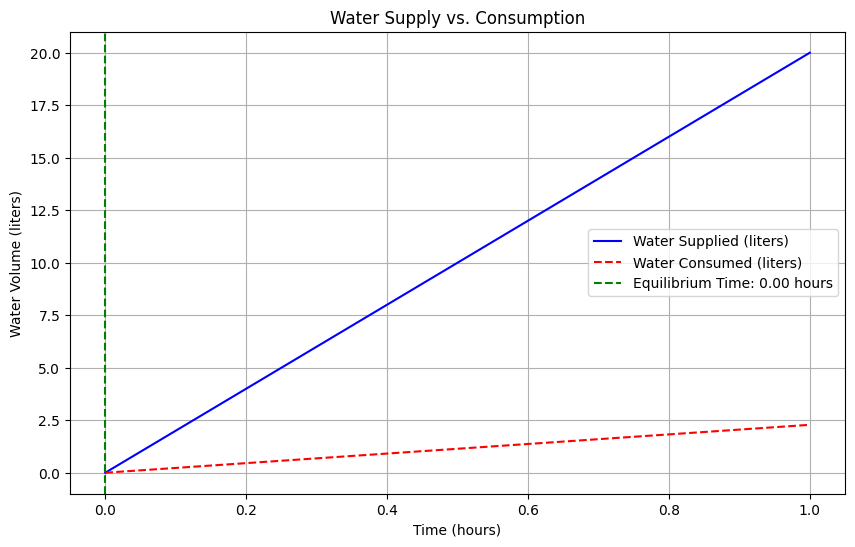

In [8]:
import matplotlib.pyplot as plt 
import numpy as np 
from sympy import symbols, Eq, solve, Float

#Define symbols
time = symbols('time') 
production_rate = Float(get_property_value(data= property_value_table,component= 'PEAK', function= 'Provide Water', group= 'Water Production Rate', prop_name= "Value")) # liters per hour 
consumption_rate = Float(get_property_value(data= property_value_table,component= 'PEAK', function= 'Provide Water', group= 'Water Production Rate', prop_name= "Value")) # liters per day, as the property value implies a daily rate 
OUC_consumption = Float(get_property_value(data= property_value_table,component= 'Operational User Community', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value")) *  Float(get_property_value(data= property_value_table,component= 'Operational User Community', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value"))
print("OUC_consumption_rate:",OUC_consumption)
FR_consumption = Float(get_property_value(data= property_value_table,component= 'First Responders', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value")) *  Float(get_property_value(data= property_value_table,component= 'First Responders', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value"))
print("FR_consumption_rate:",FR_consumption)                       
AP_consumption = Float(get_property_value(data= property_value_table,component= 'Aid Personnel', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value")) *  Float(get_property_value(data= property_value_table,component= 'Aid Personnel', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value"))
print("AP_consumption_rate:",FR_consumption)   
LP_consumption = Float(get_property_value(data= property_value_table,component= 'Local Population', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value")) *  Float(get_property_value(data= property_value_table,component= 'Local Population', function= 'Receive Water', group= 'Water Consumption Rate', prop_name= "Value"))
print("LP_consumption_rate:",FR_consumption)   
                      
daily_consumption = OUC_consumption + FR_consumption + AP_consumption +  LP_consumption  # 3.7 liters per day times the total users (from the Water Consumption Rate property)

#Convert everything to hourly rate for uniformity (since production rate is given per hour)
hourly_consumption = daily_consumption / 24 # convert daily consumption to hourly

#Define equation: production_rate * time = hourly_consumption * time
water_supplied = production_rate * time 
water_consumed = hourly_consumption * time 
equation = Eq(water_supplied, water_consumed)

#Solve for time when supplied water meets consumed water
solution = solve(equation, time)[0]

#Create a time array for simulation
times = np.linspace(0, float(solution) + 1, 100) 
water_supplied_array = production_rate * times 
water_consumed_array = hourly_consumption * times

#Plotting
plt.figure(figsize=(10, 6)) 
plt.plot(times, water_supplied_array, label='Water Supplied (liters)', color='blue') 
plt.plot(times, water_consumed_array, label='Water Consumed (liters)', color='red', linestyle='dashed') 
plt.axvline(float(solution), color='green', linestyle='--', label=f'Equilibrium Time: {float(solution):.2f} hours') 
plt.xlabel('Time (hours)') 
plt.ylabel('Water Volume (liters)') 
plt.title('Water Supply vs. Consumption') 
plt.legend() 
plt.grid(True) 
plt.show()